The goal of this notebook is to perform time series EDA. This is intended as EDA ONLY. (Not testing other classes, not performing data analysis etc.)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse

#now more time-series specific things
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

import pmdarima as pm

system_ids = [2105, 2107, 7333, 9068] #the relevant ids
#system_id = 2105 #may have to look through them eventually
#path = f'../../../../data_ds_project/systems/prize/{system_id}/'

def systemPath(system_id):
    return f'../../../../data_ds_project/systems/prize/{system_id}/'

In [3]:
#Instead of using all the data/files for EDA, we will use only some
#we begin with a list of inverters, and then add on the meters, to make sure we're choosing from all of the possibilities
individual_data = pd.read_csv('../../../../data_ds_project/systems/prize/new_inverter_names_for_prize_cleaned_power.csv')
individual_data

,system_id,old_name,new_name
0,2107,inv_01_ac_power_inv_149583,0
1,2107,inv_02_ac_power_inv_149588,1
2,2107,inv_03_ac_power_inv_149593,2
3,2107,inv_04_ac_power_inv_149598,3
4,2107,inv_05_ac_power_inv_149603,4
...,...,...,...
141,9068,inverter_module_2.2_ac_power_(kw)_inv_150140,5
142,9068,inverter_module_2.3_ac_power_(kw)_inv_150141,6
143,9068,inverter_module_2.4_ac_power_(kw)_inv_150142,7
144,9068,inverter_1_ac_power_(kw)_inv_150143,8


In [4]:
meters_df = pd.DataFrame({
    'system_id' : [2105, 9068], 
    'old_name' : ['meter','meter'], 
    'new_name' : ['000','000']
})
all_datas = pd.concat([individual_data, meters_df], ignore_index = True)
all_datas

,system_id,old_name,new_name
0,2107,inv_01_ac_power_inv_149583,0
1,2107,inv_02_ac_power_inv_149588,1
2,2107,inv_03_ac_power_inv_149593,2
3,2107,inv_04_ac_power_inv_149598,3
4,2107,inv_05_ac_power_inv_149603,4
...,...,...,...
143,9068,inverter_module_2.4_ac_power_(kw)_inv_150142,7
144,9068,inverter_1_ac_power_(kw)_inv_150143,8
145,9068,inverter_2_ac_power_(kw)_inv_150144,9
146,2105,meter,000


In [5]:
#sample 10 of them. Set a random seed too to make this reproducible 
# sample_data = all_datas.sample(148, random_state = 10)
# sample_data
sample_data = all_datas

## Naive model 

Build a naive seasonal model. 

- train test split
- next cycle = average of all previous cycles. (do this by day)

In [13]:
from extract_and_clean import Clean
sample_data = all_datas
#run it on all of them! -- but with proportions: amount generated/capacity.
# estimate capacity by using maximum daily average value
all_errors = np.zeros(len(sample_data))
systems_missing_checked = []
for i in range(len(sample_data)):

    #file name
    file_name = str(sample_data.iloc[i,0])+"_"
    if sample_data.iloc[i,1]=="meter":
        file_name = file_name + "meter_"
    else:
        file_name = file_name + "inverter_"
    file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

    df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
    df['time'] = pd.to_datetime(df['time'])

    #should check whether there are any skipped days COMMENTING THIS OUT FOR NOW so it doesn't print a bunch
    # obj = Clean()
    # missing_days = obj.missing_days(df)
    # if (len(missing_days)!=0):
    #     print(f"System_id = {sample_data.iloc[i,0]}, inverter = {str(sample_data.iloc[i,2]).zfill(3)}")
    #     systems_missing_checked.append(sample_data.iloc[i,0])
    #     print("Missing days: (there is a gap before printed day)")
    #     display(missing_days)

    #make a reasonable estimate as to the capacity -- I don't think we actually need to do this if we're not trying to extrapolate to new locations
    max = df['power'].max()
    df['proportion'] = df['power']/max

    #train test split
    X_train = df.iloc[:int(0.8*len(df))]
    X_test = df.iloc[int(0.8*len(df)):]

    #k-cross validation, since you gotta
    n_splits = 3
    kfold = TimeSeriesSplit(n_splits = n_splits)

    errors = np.zeros(n_splits) #errors array
    for j,(ind_train, ind_ho) in enumerate(kfold.split(X_train)):
        X_tt = X_train.iloc[ind_train]
        X_ho = X_train.iloc[ind_ho]
        y_ho = X_train.iloc[ind_ho,2]

        grouped_data_means = pd.DataFrame(X_tt.groupby(X_tt["time"].dt.strftime("%m-%d"))["proportion"].mean())
        grouped_data_means = grouped_data_means.squeeze()

        X_ho["month_day"] = X_ho["time"].dt.strftime("%m-%d")
        X_ho["y_pred"] = X_ho["month_day"].map(grouped_data_means)
        y_pred = X_ho['y_pred']
        #display(y_pred)
        y_pred[y_pred.isna()]=0 #some of the days are missing -- likely due to low reader output

        errors[j] = mse(y_pred, y_ho)

    errors
    all_errors[i] = errors.mean()
all_errors

array([0.04028738, 0.04824844, 0.04694141, 0.04181614, 0.06013184,
       0.0418246 , 0.04935225, 0.03558265, 0.03253747, 0.04074913,
       0.05878728, 0.03357853, 0.03522434, 0.07962161, 0.0361382 ,
       0.04568754, 0.03615803, 0.04273388, 0.03514327, 0.03408718,
       0.04350416, 0.03372833, 0.04466191, 0.04716941, 0.06709886,
       0.04729476, 0.04787494, 0.0460725 , 0.04648639, 0.04172708,
       0.05185203, 0.04603172, 0.04586493, 0.03615575, 0.03827624,
       0.05272926, 0.04432066, 0.03810624, 0.03984928, 0.03954409,
       0.05297941, 0.04404289, 0.04379318, 0.04449872, 0.04574935,
       0.04673165, 0.03860528, 0.03939066, 0.05106408, 0.04385449,
       0.03918498, 0.03888137, 0.04042872, 0.04339242, 0.03887013,
       0.04128872, 0.03843067, 0.04203943, 0.03678193, 0.04185737,
       0.05007757, 0.03921643, 0.04462709, 0.04329467, 0.04281414,
       0.0380333 , 0.0425185 , 0.04347835, 0.04499508, 0.04406826,
       0.04404617, 0.03624295, 0.05445633, 0.06022406, 0.06661

In [14]:
naive1_errors = all_errors
naive1_errors.mean()

np.float64(0.04442056157588256)

# Check autocorrelation and partial autocorrelation plots

In [5]:
#go back to the 10 samples from before
#sample 10 of them. Set a random seed too to make this reproducible 
sample_data = all_datas.sample(10, random_state = 10)
sample_data

,system_id,old_name,new_name
79,7333,sos-03-109-inv1-power-kw__176646,55
124,7333,sos-06-081-inv1-power-kw__176691,100
24,7333,sos-01-001-inv1-power-kw__176591,0
35,7333,sos-01-044-inv1-power-kw__176602,11
85,7333,sos-04-040-inv1-power-kw__176652,61
59,7333,sos-02-026-inv1-power-kw__176626,35
10,2107,inv_11_ac_power_inv_149633,10
114,7333,sos-05-101-inv1-power-kw__176681,90
140,9068,inverter_module_2.1_ac_power_(kw)_inv_150139,4
144,9068,inverter_1_ac_power_(kw)_inv_150143,8


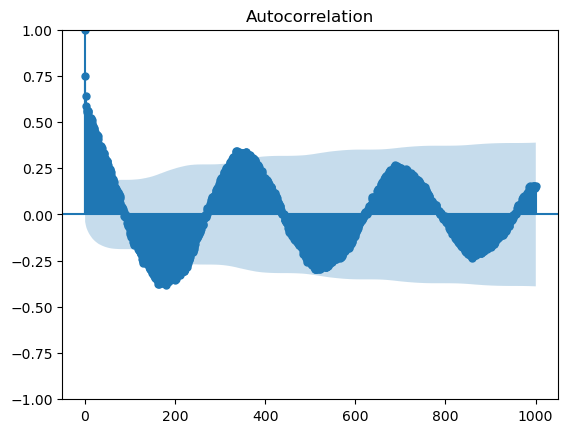

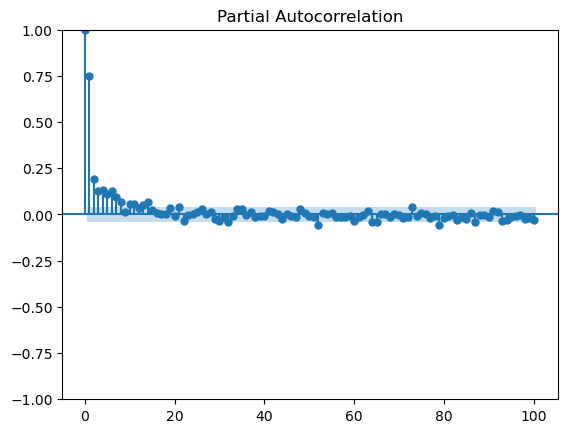

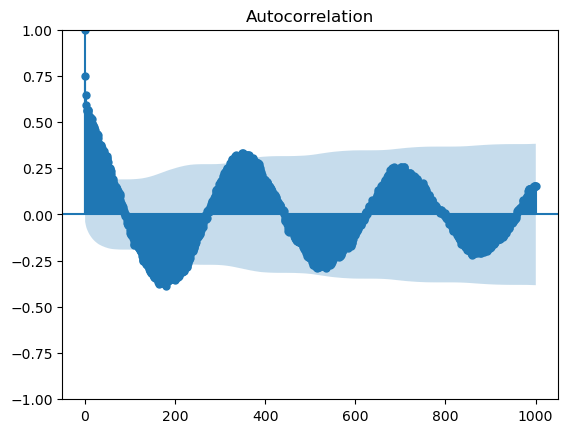

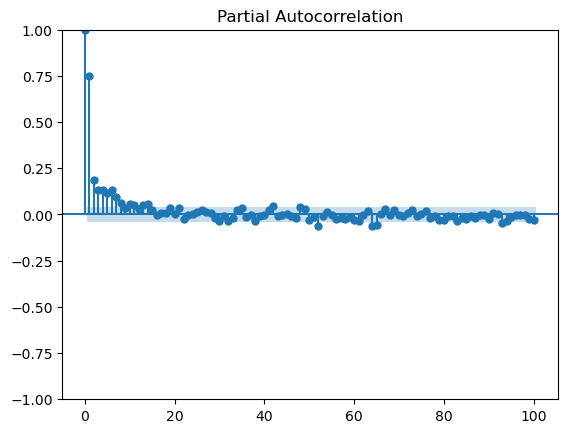

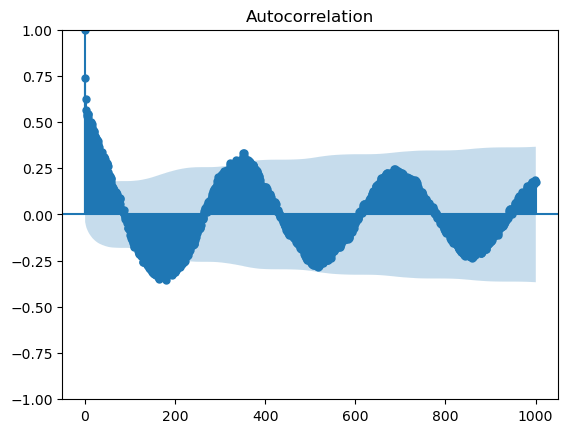

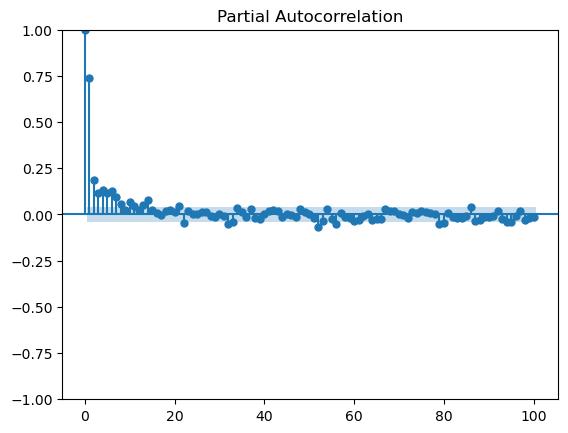

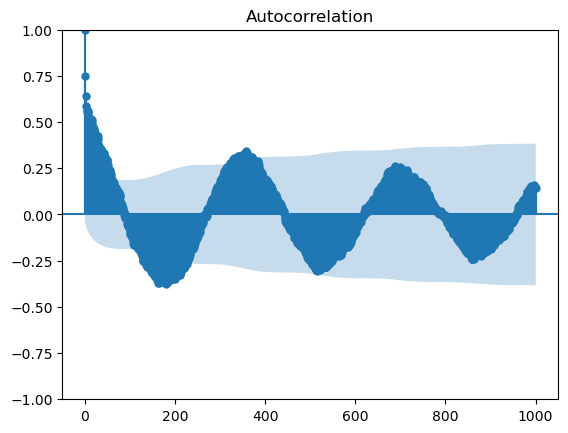

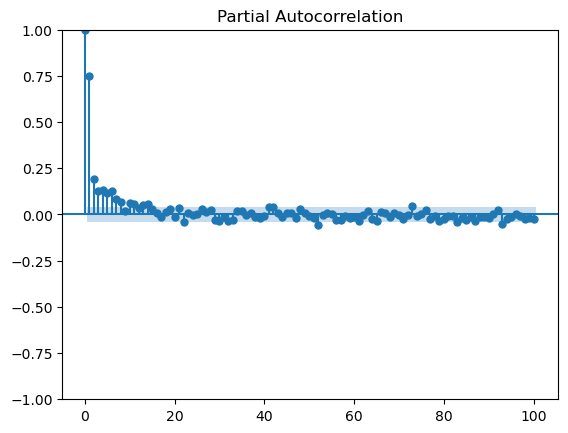

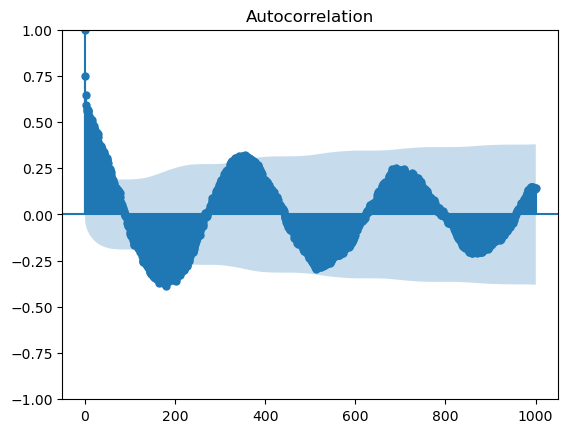

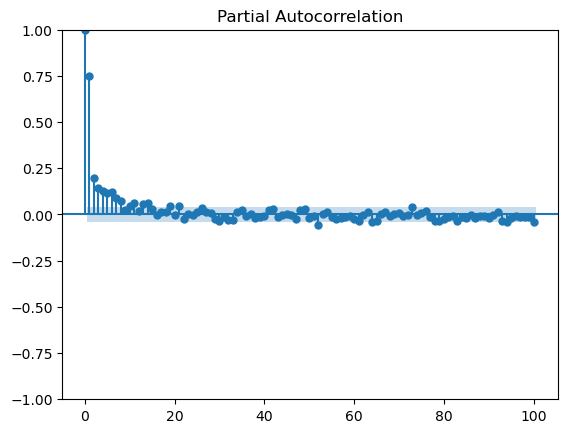

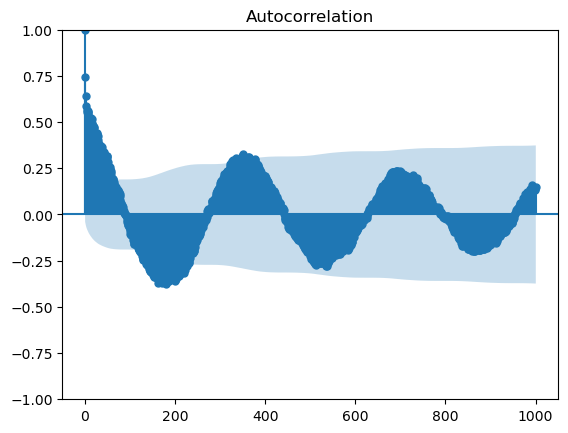

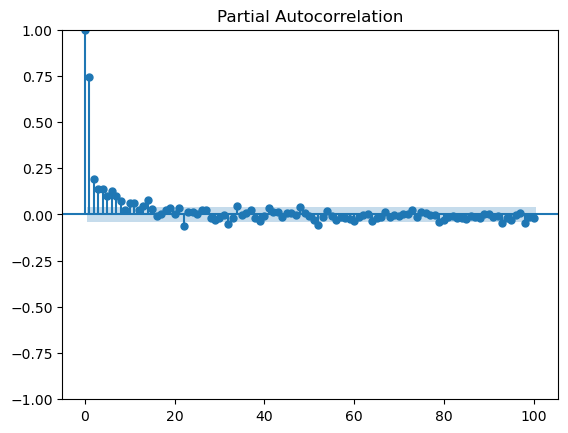

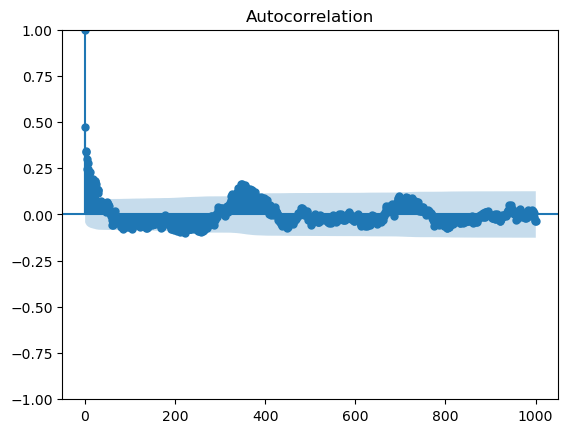

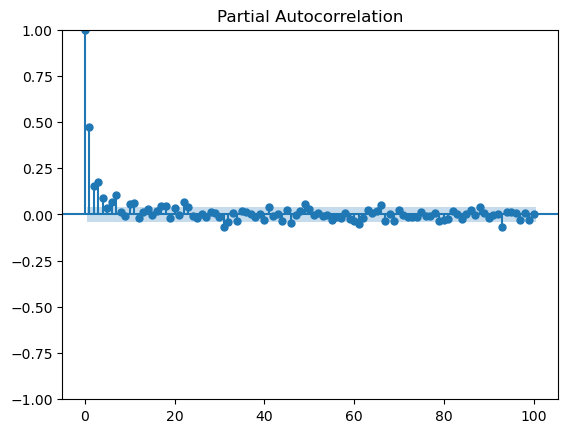

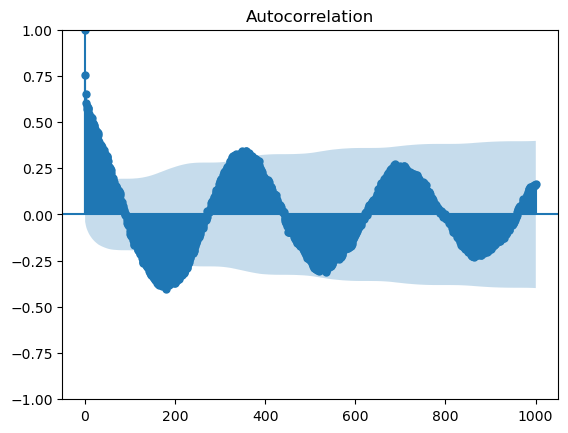

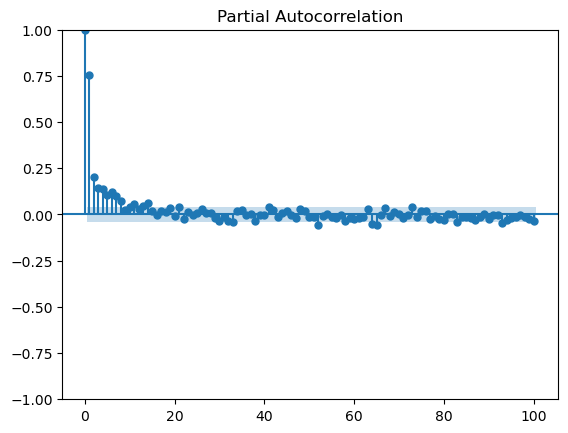

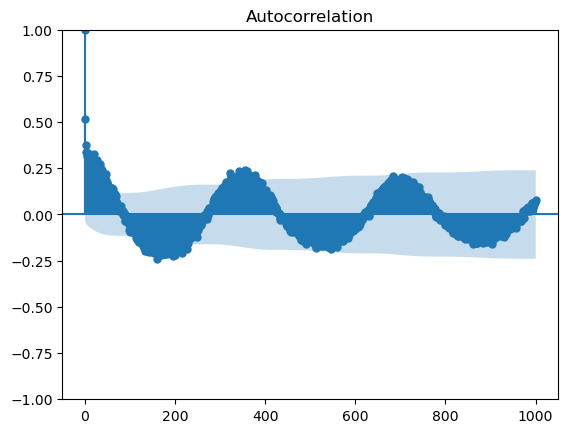

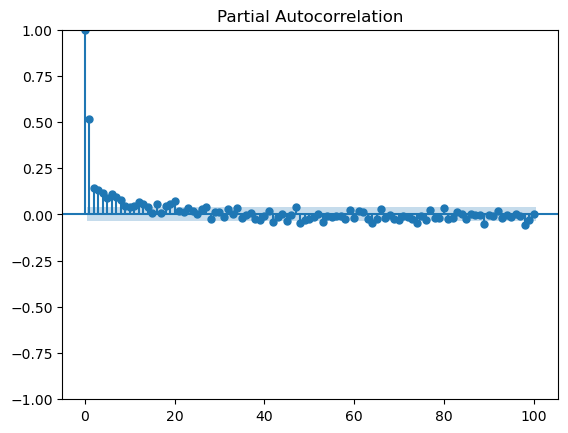

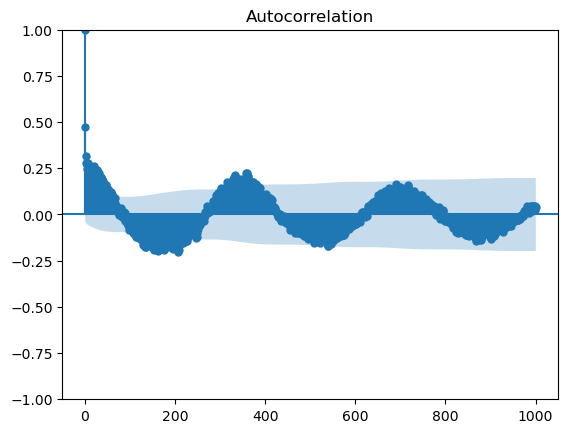

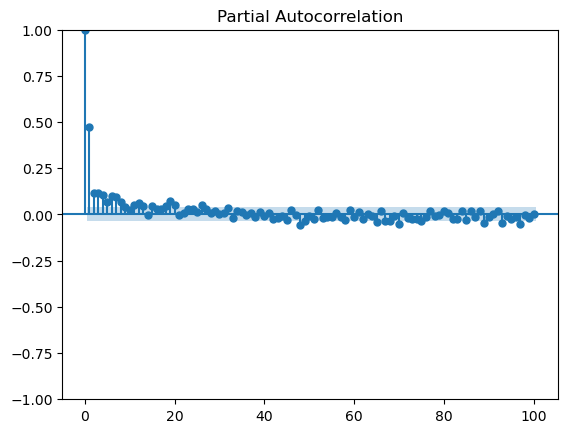

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#iterate through these to get the outputs

for i in range(len(sample_data)):
    #file name
    file_name = str(sample_data.iloc[i,0])+"_"
    if sample_data.iloc[i,1]=="meter":
        file_name = file_name + "meter_"
    else:
        file_name = file_name + "inverter_"
    file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

    df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
    df['time'] = pd.to_datetime(df['time'])

    max = df['power'].max()
    df['proportion'] = df['power']/max

    plot_acf(df['proportion'], lags = 1000)
    plot_pacf(df['proportion'], lags = 100)
    

So if looking at the plots of the data weren't enough, the autocorrelation plots are sinusoidal (with period ~mid-300's), supporting early seasonality. (No way!)

That being said, let's use some logic. Power output depends on sunlight, which depends on weather.

Weather correlates with season (thus seasonal). However, weather today can impact weather tomorrow. This means we should consider auto-regressive models. Moreover, "shocks" one day (i.e. storms) can impact future weather (rain today may mean rain tomorrow), so perhaps some aspect of moving averages can be used as well. (I'm less certain about this though, since there is often subshine after a storm.)


In [ ]:
#let's try to use auto-arima and see what happens
# NOTE: we did not put NA's into the data to denote days where data is missing

from pmdarima import auto_arima

for i in range(len(sample_data)):
    #file name
    file_name = str(sample_data.iloc[i,0])+"_"
    if sample_data.iloc[i,1]=="meter":
        file_name = file_name + "meter_"
    else:
        file_name = file_name + "inverter_"
    file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

    df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
    df['time'] = pd.to_datetime(df['time'])

    max = df['power'].max()
    df['proportion'] = df['power']/max


    model = auto_arima(df['proportion'], trace=True)
    print(model)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-2724.977, Time=2.10 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-432.714, Time=0.28 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2442.017, Time=0.15 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-1567.484, Time=0.32 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4727.461, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2705.282, Time=1.62 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-2739.450, Time=1.93 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2590.275, Time=0.96 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-2530.445, Time=0.36 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-2708.307, Time=2.19 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-2568.802, Time=0.51 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=-2735.514, Time=2.51 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-2724.645, Time=0.60 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0] intercept
Total fit time: 13.644 seconds
 ARIMA(2,0

In [ ]:
# This time, we will first put in NA's, then we will run SARIMA 
from extract_and_clean import Clean
import pmdarima as pm
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

sample_data = all_datas.sample(10, random_state = 10) #restrict what we're looking at


#for i in range(len(sample_data)):
for i in range(1): #do on only one dataset for now
    #file name
    file_name = str(sample_data.iloc[i,0])+"_"
    if sample_data.iloc[i,1]=="meter":
        file_name = file_name + "meter_"
    else:
        file_name = file_name + "inverter_"
    file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

    df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
    df['time'] = pd.to_datetime(df['time'])

    max = df['power'].max()
    df['proportion'] = df['power']/max

    #fill in empty times 
    obj = Clean()
    new_df = obj.fill_missing_days_na(df)
    #display(new_df)

    #should do a train/test split
    new_df_train = new_df.loc[:0.8*int(len(new_df))]

    #do a search for best parameters-- can't do toooo much or else it'll overfit
    best_aic = float("inf")
    best_order = None

    for p, d, q in itertools.product(range(3), range(2), range(3)):
        try:
            model = SARIMAX(new_df_train['proportion'], order=(p,d,q), seasonal_order = (1,0,0,365))
            res = model.fit(disp=False)
            
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p,d,q)
        except:
            continue

    print(best_order)

    print(model)

In [9]:
from pmdarima import auto_arima

i=0
file_name = str(sample_data.iloc[i,0])+"_"
if sample_data.iloc[i,1]=="meter":
    file_name = file_name + "meter_"
else:
    file_name = file_name + "inverter_"
file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
df['time'] = pd.to_datetime(df['time'])

max = df['power'].max()
df['proportion'] = df['power']/max

model = auto_arima(df['proportion'], seasonal = True, m=365)
model.summary()


MemoryError: Unable to allocate 2.48 GiB for an array with shape (904912, 368) and data type float64

In [ ]:
#That was too computationally intensive... what if we try the differenced version?
from pmdarima import auto_arima

i=0
file_name = str(sample_data.iloc[i,0])+"_"
if sample_data.iloc[i,1]=="meter":
    file_name = file_name + "meter_"
else:
    file_name = file_name + "inverter_"
file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
df['time'] = pd.to_datetime(df['time'])

max = df['power'].max()
df['proportion'] = df['power']/max

#Also need to do the train/test split with 80% of data
df_train = df.iloc[:int(0.8*len(df))]


,time,power,proportion
365,365 days,-237.490184,-0.144545
366,365 days,-876.261400,-0.533323
367,365 days,-784.727817,-0.477612
368,365 days,-694.573983,-0.422741
369,365 days,-445.547257,-0.271175
...,...,...,...
1962,392 days,-5.288322,-0.003219
1963,392 days,-327.203233,-0.199147
1964,392 days,-379.490817,-0.230971
1965,392 days,-22.540971,-0.013719


In [6]:
#let's try to use auto-arima and see what happens
# NOTE: we did not put NA's into the data to denote days where data is missing
# do the train test split

from pmdarima import auto_arima
sample_data = all_datas.head(10)

errors = np.zeros(len(sample_data))
for i in range(len(sample_data)):
    #file name
    file_name = str(sample_data.iloc[i,0])+"_"
    if sample_data.iloc[i,1]=="meter":
        file_name = file_name + "meter_"
    else:
        file_name = file_name + "inverter_"
    file_name = file_name + str(sample_data.iloc[i,2]).zfill(3) + ".csv"

    df = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{file_name}')
    #print(f"System_id = {str(sample_data.iloc[i,0])}")

    #turn strings into daytime
    df['time'] = pd.to_datetime(df['time'])

    max = df['power'].max()
    df['proportion'] = df['power']/max

    #train test split
    df_train = df.loc[:int(0.8*len(df))]
    df_test = df.loc[int(0.8*len(df)):]


    model = auto_arima(df['proportion'], trace=True)
    print(model)
    y_pred = model.predict(len(df)-int(0.8*len(df)))
    errors[i] = mse(y_pred, df_test['proportion'])
    

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-2163.728, Time=1.58 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1386.375, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1703.738, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-2104.036, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1388.375, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-2165.058, Time=1.98 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-2166.458, Time=1.66 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-2164.736, Time=2.85 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-2166.930, Time=1.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-2164.959, Time=1.79 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-1923.102, Time=0.48 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-2168.921, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-2106.035, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-1705.738, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0

In [7]:
print(errors)

[0.02824674 0.03371911 0.03428377 0.03007134 0.03270619 0.03113886
 0.03157014 0.02501707 0.02502842 0.02499087]


# Comparing sunlight duration to power output

First set is colored by season

Second set is colored by month

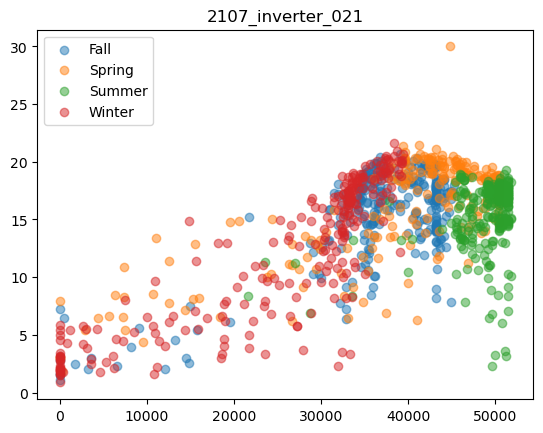

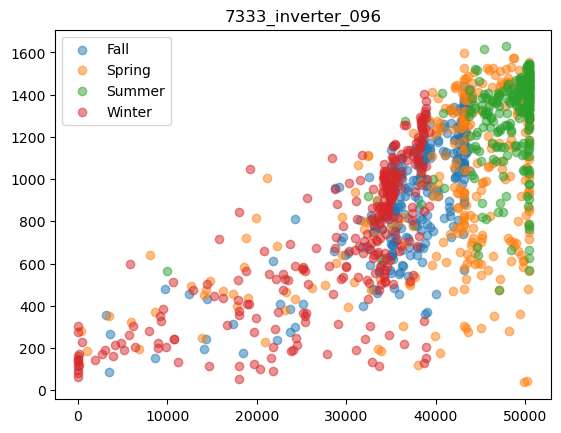

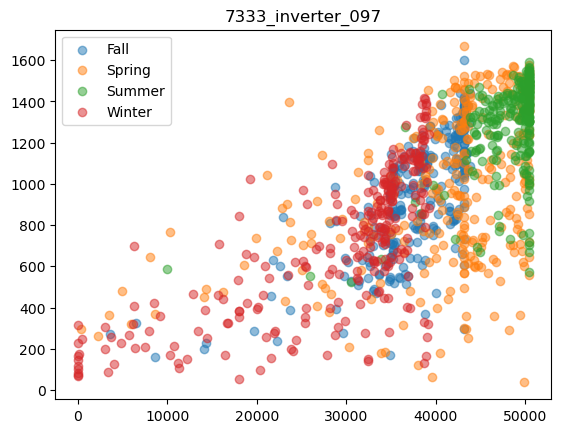

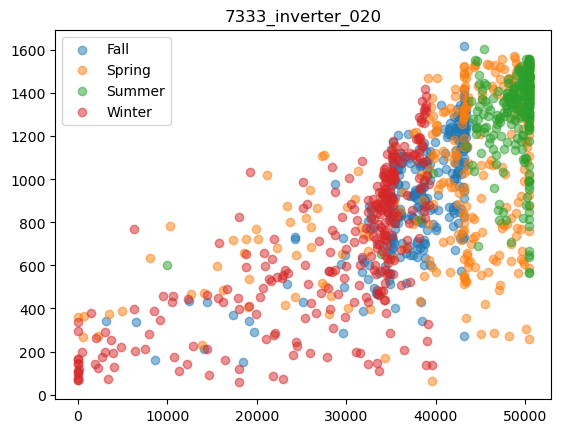

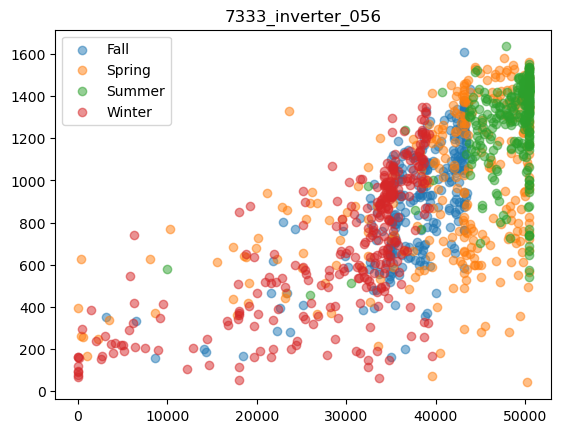

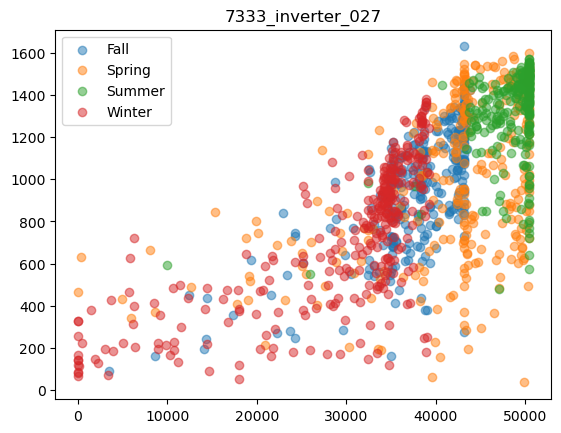

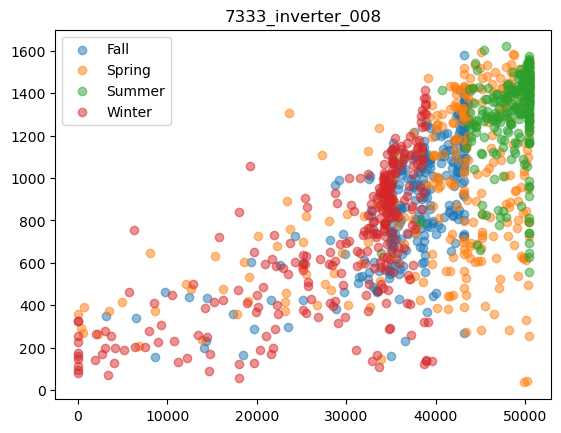

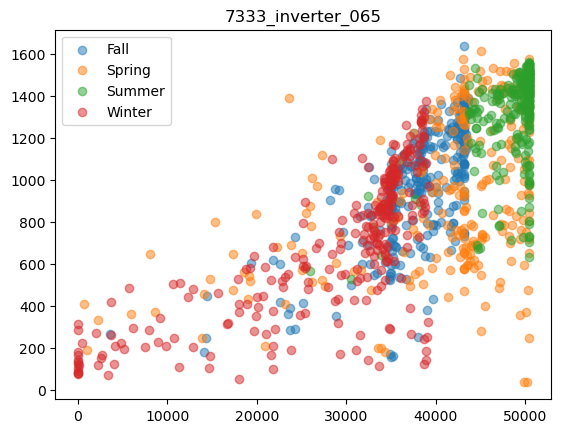

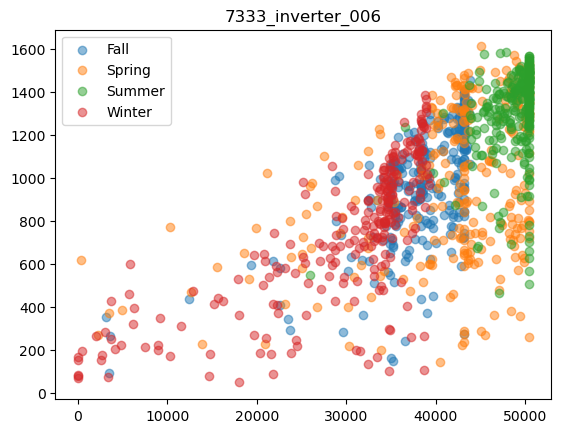

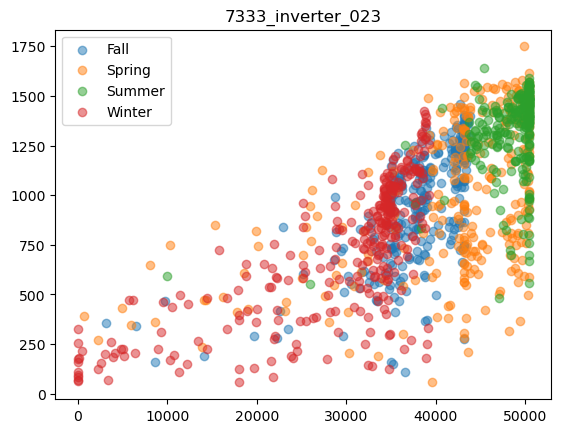

In [37]:
#want to see whether there's a relationship between sunshine hours and ac power output
for i in range(len(all_datas)):
    all_datas.iloc[i,2] = str(all_datas['new_name'][i]).zfill(3)
all_datas['file_name'] = (all_datas['system_id'].astype(str) + "_"
                          + np.where(all_datas['old_name'] == 'meter', 'meter', 'inverter') + "_"
                          + all_datas['new_name'].astype(str))
all_datas

#choose small sample
sample_data = all_datas.sample(10)
sample_data = sample_data.sort_values(by = 'system_id')
#display(sample_data)

def sort_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Fall'


#iterate through systems
for id in sample_data['system_id'].unique():
    weather = pd.read_csv(f"prize_weather/{str(id)}.csv")
    #add a 'season' column
    #   W = winter: dec, jan, feb
    #   Sp = spring: March, apr, may
    #   Su = summer: June, July, Aug
    #   F = fall: sept, oct nov
    weather['time'] = pd.to_datetime(weather['time'])
    
    weather['season'] = weather['time'].dt.month.apply(sort_season)
    #display(weather)

    #make the date the index -- easier for future merging
    weather = weather.set_index('time')
    for system in sample_data.loc[sample_data['system_id']==id].itertuples():
        power_info = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{system[4]}.csv')
        power_info['time'] = pd.to_datetime(power_info['time'])
        power_info = power_info.set_index('time')
        #merge weather and power_info
        df = pd.concat([weather, power_info], axis = 1)
        df = df.dropna()
        #display(df)

        df_rand = df.sample(int(0.5*len(df)))

        #create plot
        for season,group in df_rand.groupby('season'):
            plt.scatter(group['sunshine_duration'], group['power'],alpha = 0.5, label = season)
        plt.legend()
        plt.title(system[4])
        plt.show()


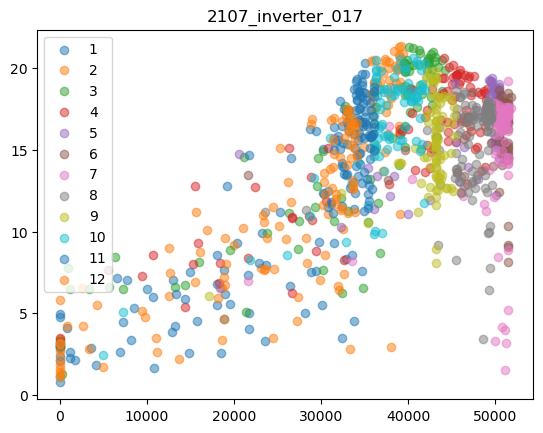

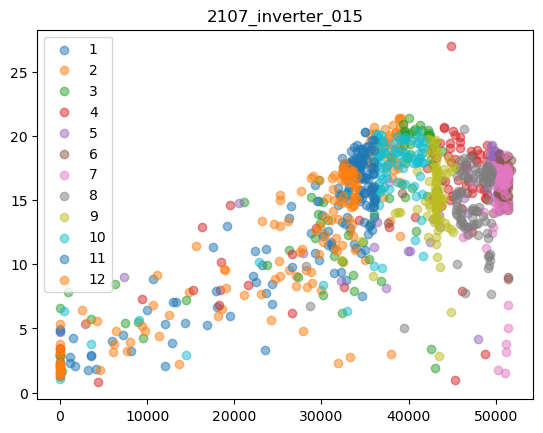

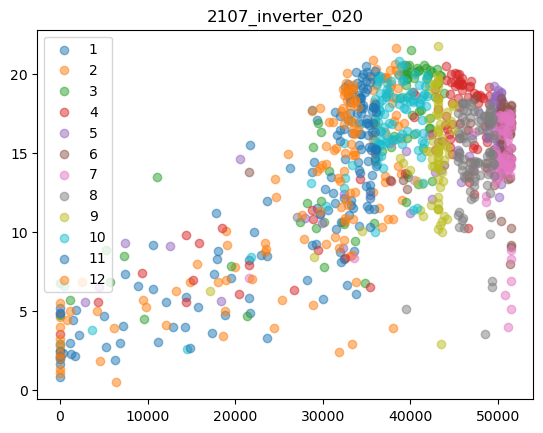

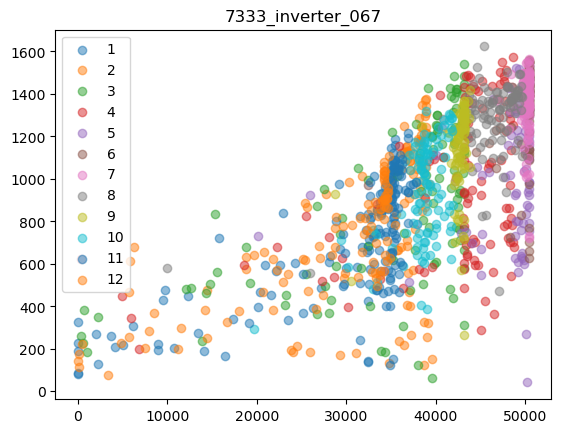

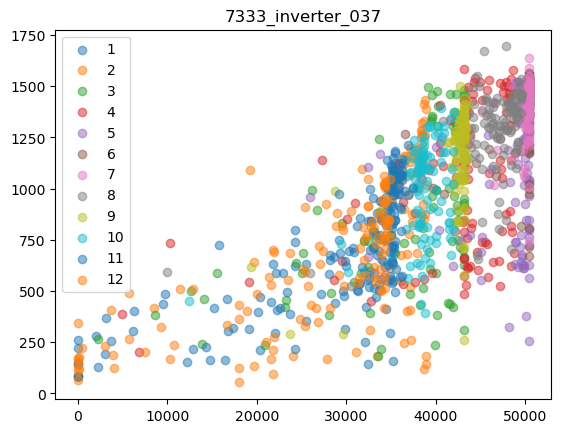

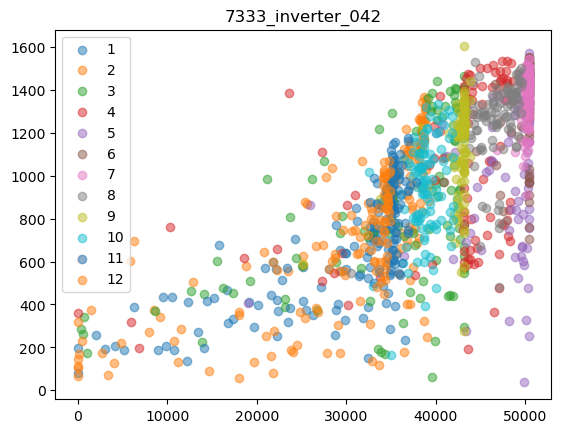

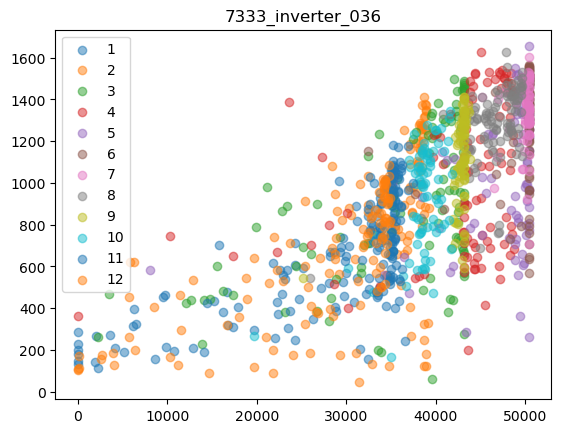

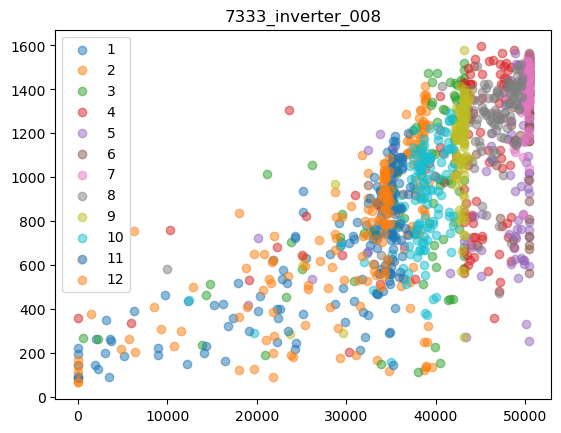

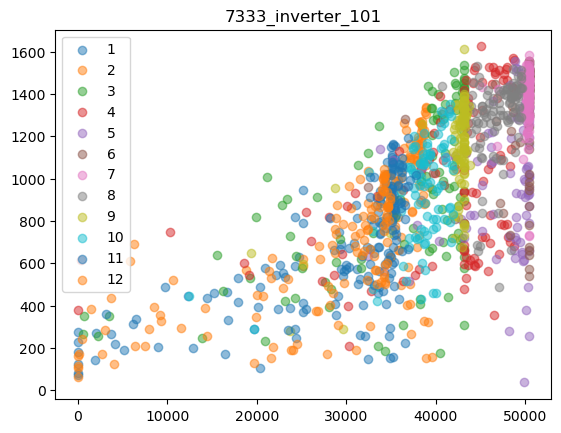

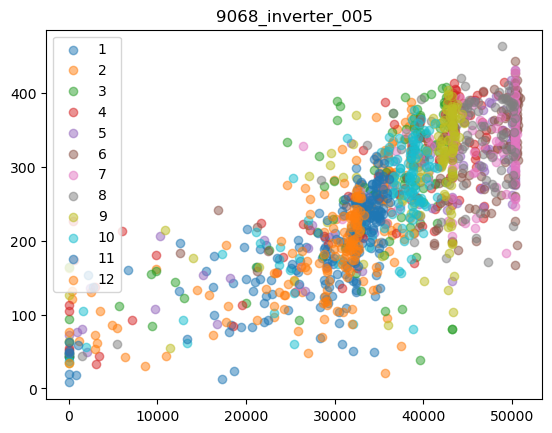

In [38]:
#want to see whether there's a relationship between sunshine hours and ac power output
for i in range(len(all_datas)):
    all_datas.iloc[i,2] = str(all_datas['new_name'][i]).zfill(3)
all_datas['file_name'] = (all_datas['system_id'].astype(str) + "_"
                          + np.where(all_datas['old_name'] == 'meter', 'meter', 'inverter') + "_"
                          + all_datas['new_name'].astype(str))
all_datas

#choose small sample
sample_data = all_datas.sample(10)
sample_data = sample_data.sort_values(by = 'system_id')
#display(sample_data)

def sort_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Fall'


#iterate through systems
for id in sample_data['system_id'].unique():
    weather = pd.read_csv(f"prize_weather/{str(id)}.csv")
    #add a 'season' column
    #   W = winter: dec, jan, feb
    #   Sp = spring: March, apr, may
    #   Su = summer: June, July, Aug
    #   F = fall: sept, oct nov
    weather['time'] = pd.to_datetime(weather['time'])
    
    weather['month'] = weather['time'].dt.month
    #display(weather)

    #make the date the index -- easier for future merging
    weather = weather.set_index('time')
    for system in sample_data.loc[sample_data['system_id']==id].itertuples():
        power_info = pd.read_csv(f'../../../../data_ds_project/systems/prize/prize_cleaned_power/{system[4]}.csv')
        power_info['time'] = pd.to_datetime(power_info['time'])
        power_info = power_info.set_index('time')
        #merge weather and power_info
        df = pd.concat([weather, power_info], axis = 1)
        df = df.dropna()
        #display(df)

        df_rand = df.sample(int(0.5*len(df)))

        #create plot
        for season,group in df_rand.groupby('month'):
            plt.scatter(group['sunshine_duration'], group['power'],alpha = 0.5, label = season)
        plt.legend()
        plt.title(system[4])
        plt.show()